In [61]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


import warnings
warnings.filterwarnings("ignore")


import mlflow
import mlflow.sklearn

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, TargetEncoder
from sklearn.base import clone

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report
)

pd.set_option("display.width", 130)


sns.set(style="whitegrid")


In [35]:
df = pd.read_csv('data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [36]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [37]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 1081


In [38]:
df[df.duplicated() ==True][:10]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
221,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0
223,145.0,-2.419486,1.949346,0.552998,0.982710,-0.284815,2.411200,-1.398537,-0.188922,0.675695,...,1.213390,-1.238354,0.007191,-1.724175,0.239721,-0.313607,-0.187431,0.119472,6.74,0
1178,919.0,0.904289,-0.538055,0.396058,0.500680,-0.864473,-0.657199,0.027231,-0.029473,0.265447,...,-0.099460,-0.597579,-0.048666,0.551824,0.182934,0.402176,-0.081357,0.027252,158.00,0
1180,919.0,1.207596,-0.036860,0.572104,0.373148,-0.709633,-0.713698,-0.181105,0.011277,0.283940,...,-0.194591,-0.514717,0.089714,0.543768,0.240581,0.418921,-0.051693,-0.000085,1.00,0
1382,1074.0,-2.248488,-0.195670,0.026949,-0.525780,-0.238759,-0.033359,0.162196,0.928520,-0.424215,...,-0.032208,-0.745757,-0.243193,-0.821633,-0.030402,0.335838,-0.286998,-0.243768,158.00,0


In [39]:
df = df.drop_duplicates().reset_index(drop=True)
df.shape

(283726, 31)

In [40]:
mlflow.set_tracking_uri("sqlite:///mlflow_fraud.db")
mlflow.set_experiment("classification_for_credit_card_fraud")

print("Tracking URI:", mlflow.get_tracking_uri())
print("Active experiment:", mlflow.get_experiment_by_name("classification_for_credit_card_fraud").name)


Tracking URI: sqlite:///mlflow_fraud.db
Active experiment: classification_for_credit_card_fraud


In [41]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17',
       'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class'],
      dtype='object')

In [50]:
X = df.drop(columns=['Class'])
y = df['Class']

In [51]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [52]:
y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(Class
 0    0.998335
 1    0.001665
 Name: proportion, dtype: float64,
 Class
 0    0.998326
 1    0.001674
 Name: proportion, dtype: float64)

In [55]:
raw_cols = ['Time', 'Amount']
pca_cols = [f'V{i}' for i in range(1, 29)]


num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


processor = ColumnTransformer([
    ('num', num_pipeline, raw_cols),
    ('pca_pass', 'passthrough', pca_cols)
])



In [56]:
processor.fit(x_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('pca_pass', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

In [57]:
x_train_transformed = processor.transform(x_train)
x_test_transformed = processor.transform(x_test)

In [64]:
scale_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

In [74]:
classifier = {
    'Logistic Regression' : (LogisticRegression, {"max_iter":1000}),
    'Naive Bayes': (GaussianNB, {}),
    'Decision Tree': (DecisionTreeClassifier, {"random_state": 42}),
    'KNN': (KNeighborsClassifier, {}),
    'SVM': (SVC, {}),
    'Random Forest': (RandomForestClassifier, {"random_state":42}),
    'XGBoost' : (XGBClassifier, {"scale_pos_weight":scale_weight, "eval_metric":'aucpr', "n_estimators":200}),
    'CatBoost': (CatBoostClassifier, {"scale_pos_weight":scale_weight, "eval_metric":'AUC', "verbose":0})
}

In [77]:
run_ids={}

for name, (ModelClass, params) in classifier.items():
    with mlflow.start_run(run_name=name) as run:
        mlflow.set_tag('algorithm', name)
        mlflow.log_params(params)
        print(params)
        model = ModelClass(**params)
        model.fit(x_train_transformed, y_train)

        preds = model.predict(x_test_transformed)
        proba = model.predict_proba(x_test_transformed)[:,1] if hasattr(model, 'predict_proba') else None

        metrics = {
            "accuracy": accuracy_score(y_test, preds),
            "precision": precision_score(y_test, preds),
            "recall": recall_score(y_test, preds),
            "F1": f1_score(y_test, preds)
        }

        if proba is not None:
            metrics['roc_auc'] = roc_auc_score(y_test, proba)
        
        mlflow.log_metrics(metrics)
        mlflow.sklearn.log_model(model, name='model',input_example=x_train_transformed[:2], skops_trusted_types=[
        "xgboost.core.Booster", 
        "xgboost.sklearn.XGBClassifier",
        "catboost.core.CatBoostClassifier",
        "catboost.CatBoostClassifier"
    ])

        run_ids[name] = run.info.run_id
        print(f"{name:22s} run_id={run.info.run_id}  f1={metrics['F1']:.3f}  acc={metrics['accuracy']:.3f}") 

{'max_iter': 1000}


2026/07/17 20:57:48 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/17 20:57:48 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/17 20:57:48 INFO mlflow.utils.environment: Detected uv project at c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection. Attempting to export requirements via 'uv export'.
2026/07/17 20:57:48 INFO mlflow.utils.uv_utils: Exported 179 dependencies via uv
2026/07/17 20:57:48 INFO mlflow.utils.environment: Successfully exported 179 requirements from uv project. Skipping package capture based inference.
2026/07/17 20:57:48 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Logistic Regression    run_id=8907c43ee32f4cb584dc029537f811b3  f1=0.696  acc=0.999
{}


2026/07/17 20:57:50 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/17 20:57:50 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/17 20:57:50 INFO mlflow.utils.environment: Detected uv project at c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection. Attempting to export requirements via 'uv export'.
2026/07/17 20:57:50 INFO mlflow.utils.uv_utils: Exported 179 dependencies via uv
2026/07/17 20:57:50 INFO mlflow.utils.environment: Successfully exported 179 requirements from uv project. Skipping package capture based inference.
2026/07/17 20:57:51 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Naive Bayes            run_id=15fa6501634d48a793ff4f798c036dbd  f1=0.108  acc=0.978
{'random_state': 42}


2026/07/17 20:58:15 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/17 20:58:15 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/17 20:58:15 INFO mlflow.utils.environment: Detected uv project at c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection. Attempting to export requirements via 'uv export'.
2026/07/17 20:58:15 INFO mlflow.utils.uv_utils: Exported 179 dependencies via uv
2026/07/17 20:58:15 INFO mlflow.utils.environment: Successfully exported 179 requirements from uv project. Skipping package capture based inference.
2026/07/17 20:58:16 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Decision Tree          run_id=66dce7ebacec4f8ba387a3f5d98d4774  f1=0.706  acc=0.999
{}


2026/07/17 20:58:58 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/17 20:58:59 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/17 20:58:59 INFO mlflow.utils.environment: Detected uv project at c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection. Attempting to export requirements via 'uv export'.
2026/07/17 20:58:59 INFO mlflow.utils.uv_utils: Exported 179 dependencies via uv
2026/07/17 20:58:59 INFO mlflow.utils.environment: Successfully exported 179 requirements from uv project. Skipping package capture based inference.
2026/07/17 20:58:59 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


KNN                    run_id=027361ab21e440dfbbbaa05a820e1884  f1=0.817  acc=0.999
{}


2026/07/17 21:00:26 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/17 21:00:27 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/17 21:00:27 INFO mlflow.utils.environment: Detected uv project at c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection. Attempting to export requirements via 'uv export'.
2026/07/17 21:00:27 INFO mlflow.utils.uv_utils: Exported 179 dependencies via uv
2026/07/17 21:00:27 INFO mlflow.utils.environment: Successfully exported 179 requirements from uv project. Skipping package capture based inference.
2026/07/17 21:00:27 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


SVM                    run_id=4a15f230312542c2b672151ffb358bf2  f1=0.761  acc=0.999
{'random_state': 42}


2026/07/17 21:02:53 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/17 21:02:53 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/17 21:02:53 INFO mlflow.utils.environment: Detected uv project at c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection. Attempting to export requirements via 'uv export'.
2026/07/17 21:02:53 INFO mlflow.utils.uv_utils: Exported 179 dependencies via uv
2026/07/17 21:02:53 INFO mlflow.utils.environment: Successfully exported 179 requirements from uv project. Skipping package capture based inference.
2026/07/17 21:02:53 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Random Forest          run_id=a4887803117b4f9781817c0b7b7c7aad  f1=0.836  acc=1.000
{'scale_pos_weight': np.float64(599.4761904761905), 'eval_metric': 'aucpr', 'n_estimators': 200}


2026/07/17 21:02:58 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/17 21:02:58 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/17 21:02:58 INFO mlflow.utils.environment: Detected uv project at c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection. Attempting to export requirements via 'uv export'.
2026/07/17 21:02:58 INFO mlflow.utils.uv_utils: Exported 179 dependencies via uv
2026/07/17 21:02:58 INFO mlflow.utils.environment: Successfully exported 179 requirements from uv project. Skipping package capture based inference.
2026/07/17 21:02:58 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


XGBoost                run_id=2e7354861e154b89bcbe32a80c8dfa6f  f1=0.860  acc=1.000
{'scale_pos_weight': np.float64(599.4761904761905), 'eval_metric': 'AUC', 'verbose': 0}


2026/07/17 21:03:27 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/17 21:03:27 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/17 21:03:27 INFO mlflow.utils.environment: Detected uv project at c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection. Attempting to export requirements via 'uv export'.
2026/07/17 21:03:27 INFO mlflow.utils.uv_utils: Exported 179 dependencies via uv
2026/07/17 21:03:27 INFO mlflow.utils.environment: Successfully exported 179 requirements from uv project. Skipping package capture based inference.
2026/07/17 21:03:27 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


CatBoost               run_id=b4fe73ccc45f4138a7df102cd73aa582  f1=0.813  acc=0.999


In [88]:
runs_df.columns

Index(['run_id', 'experiment_id', 'status', 'artifact_uri', 'start_time', 'end_time', 'metrics.roc_auc', 'metrics.precision',
       'metrics.accuracy', 'metrics.recall', 'metrics.F1', 'params.scale_pos_weight', 'params.eval_metric', 'params.verbose',
       'params.n_estimators', 'params.random_state', 'params.max_iter', 'params.c', 'tags.mlflow.source.name', 'tags.algorithm',
       'tags.mlflow.user', 'tags.mlflow.source.type', 'tags.mlflow.runName'],
      dtype='object')

In [89]:
experiment = mlflow.get_experiment_by_name("classification_for_credit_card_fraud")
runs_df = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

metric_cols = [c for c in runs_df.columns if c.startswith("metrics.")]

comparison = runs_df[["run_id", "tags.algorithm"] + metric_cols].sort_values(
    "metrics.F1", ascending=False
).reset_index(drop=True)

comparison.columns= [c.replace("metrics.", "") for c in comparison.columns]
comparison

,run_id,tags.algorithm,roc_auc,precision,accuracy,recall,F1
0,2e7354861e154b89bcbe32a80c8dfa6f,XGBoost,0.972716,0.961039,0.999577,0.778947,0.860465
1,7e6406ff45964603b7d307972cb5cf9f,XGBoost,0.972716,0.961039,0.999577,0.778947,0.860465
2,ac788816d01e469aadd96b09096239b1,Random Forest,0.919092,0.985714,0.999524,0.726316,0.836364
3,a4887803117b4f9781817c0b7b7c7aad,Random Forest,0.919092,0.985714,0.999524,0.726316,0.836364
4,027361ab21e440dfbbbaa05a820e1884,KNN,0.899889,0.971014,0.999471,0.705263,0.817073
5,992bafa858f1424b9c1ed35a8b914d0e,KNN,0.899889,0.971014,0.999471,0.705263,0.817073
6,b4fe73ccc45f4138a7df102cd73aa582,CatBoost,0.963476,0.826087,0.999383,0.800000,0.812834
7,4a15f230312542c2b672151ffb358bf2,SVM,NaN,0.983333,0.999348,0.621053,0.761290
8,f173c48e56a3492abe9e84b4e141439a,SVM,NaN,0.983333,0.999348,0.621053,0.761290
9,048b513843e447ab9f699839cfed33be,Decision Tree,0.847139,0.717391,0.999031,0.694737,0.705882


In [101]:
comparison.drop_duplicates()

,run_id,tags.algorithm,roc_auc,precision,accuracy,recall,F1
0,2e7354861e154b89bcbe32a80c8dfa6f,XGBoost,0.972716,0.961039,0.999577,0.778947,0.860465
1,7e6406ff45964603b7d307972cb5cf9f,XGBoost,0.972716,0.961039,0.999577,0.778947,0.860465
2,ac788816d01e469aadd96b09096239b1,Random Forest,0.919092,0.985714,0.999524,0.726316,0.836364
3,a4887803117b4f9781817c0b7b7c7aad,Random Forest,0.919092,0.985714,0.999524,0.726316,0.836364
4,027361ab21e440dfbbbaa05a820e1884,KNN,0.899889,0.971014,0.999471,0.705263,0.817073
5,992bafa858f1424b9c1ed35a8b914d0e,KNN,0.899889,0.971014,0.999471,0.705263,0.817073
6,b4fe73ccc45f4138a7df102cd73aa582,CatBoost,0.963476,0.826087,0.999383,0.800000,0.812834
7,4a15f230312542c2b672151ffb358bf2,SVM,NaN,0.983333,0.999348,0.621053,0.761290
8,f173c48e56a3492abe9e84b4e141439a,SVM,NaN,0.983333,0.999348,0.621053,0.761290
9,048b513843e447ab9f699839cfed33be,Decision Tree,0.847139,0.717391,0.999031,0.694737,0.705882


TypeError: 'Series' object cannot be interpreted as an integer

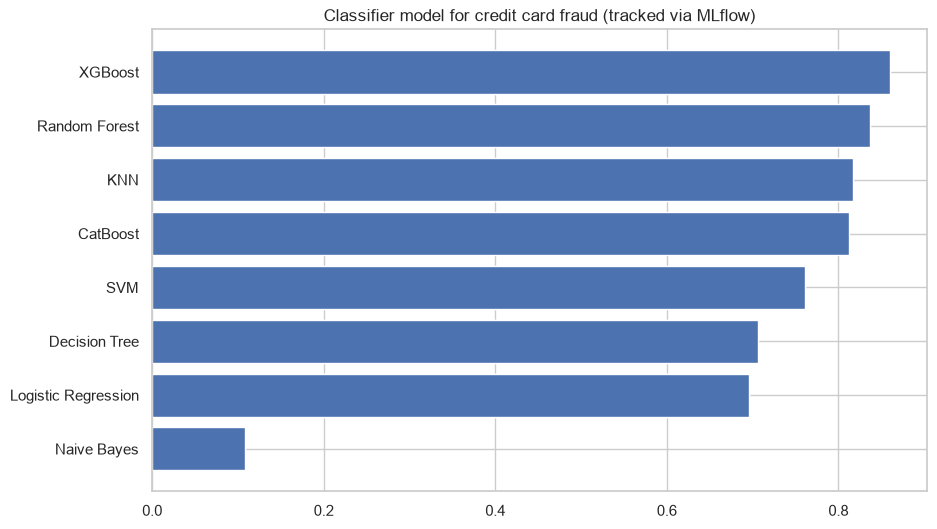

In [98]:
fig, ax = plt.subplots(figsize=(10, 6))

ordered = comparison.sort_values('F1')
ax.barh(ordered["tags.algorithm"], ordered["F1"])
ax.set_title("Classifier model for credit card fraud (tracked via MLflow)")
for i, v in enumerate(ordered["tags.algorithm"],ordered["F1"]):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center")